# Predicting 2026 World Cup Outcomes with Machine Learning

## Tutorial for New Data Science Interns

**Goal**: Build a machine learning model to predict match outcomes using historical data.

**What you'll learn**:
1. Data exploration and cleaning
2. Feature engineering (creating useful predictors)
3. Training a classification model
4. Evaluating model performance

**Dataset**: International football match results from 1872-2024

In [2]:
!pip install pandas numpy scikit-learn oracledb matplotlib seaborn joblib

In [ ]:
import oracledb

# Local 26ai ADB-Free container connection
username = "worldcup"
password = "YourPassword123#"
dsn = "myatp_low"

connection = oracledb.connect(
    user=username,
    password=password,
    dsn=dsn,
    config_dir="./wallet",
    wallet_location="./wallet",
    wallet_password='WorldCupDB1234'
)
print("Connected to Oracle!")

In [ ]:
# Load data from Oracle table
query = """
    SELECT 
        DATE_RW as "date",
        HOME_TEAM as home_team,
        AWAY_TEAM as away_team,
        HOME_SCORE as home_score,
        AWAY_SCORE as away_score,
        TOURNAMENT as tournament,
        CITY as city,
        COUNTRY as country,
        NEUTRAL as neutral
    FROM MATCH_RESULTS
"""

## Step 1: Import Libraries

These are the tools we'll use:

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# For better display
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## Step 2: Load and Explore the Data

First, let's see what data we have:

In [6]:
# Load the historical results
df = pd.read_sql(query, connection)
connection.close()

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

/tmp/ipykernel_21050/1159803907.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Dataset shape: (48943, 9)

Columns: ['date', 'HOME_TEAM', 'AWAY_TEAM', 'HOME_SCORE', 'AWAY_SCORE', 'TOURNAMENT', 'CITY', 'COUNTRY', 'NEUTRAL']

First few rows:


,date,HOME_TEAM,AWAY_TEAM,HOME_SCORE,AWAY_SCORE,TOURNAMENT,CITY,COUNTRY,NEUTRAL
0,1927-10-30,Argentina,Bolivia,7,1,Copa América,Lima,Peru,True
1,1927-11-01,Peru,Uruguay,0,4,Copa América,Lima,Peru,False
2,1927-11-06,Bolivia,Uruguay,0,9,Copa América,Lima,Peru,True
3,1927-11-13,Peru,Bolivia,3,2,Copa América,Lima,Peru,False
4,1927-11-20,Argentina,Uruguay,3,2,Copa América,Lima,Peru,True


In [7]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48943 entries, 0 to 48942
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        48943 non-null  datetime64[us]
 1   HOME_TEAM   48943 non-null  str           
 2   AWAY_TEAM   48943 non-null  str           
 3   HOME_SCORE  48943 non-null  int64         
 4   AWAY_SCORE  48943 non-null  int64         
 5   TOURNAMENT  48943 non-null  str           
 6   CITY        48943 non-null  str           
 7   COUNTRY     48943 non-null  str           
 8   NEUTRAL     48943 non-null  bool          
dtypes: bool(1), datetime64[us](1), int64(2), str(5)
memory usage: 5.3 MB


## Step 3: Data Cleaning

We need to prepare the data for machine learning:

In [ ]:
df.columns = df.columns.str.lower()

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Convert neutral from string to boolean (local DB returns 'TRUE'/'FALSE' strings)
if df['neutral'].dtype == object:
    df['neutral'] = df['neutral'].map({'TRUE': True, 'FALSE': False})

# Extract year (we'll use recent data for better predictions)
df['year'] = df['date'].dt.year

# Filter for recent matches (last 20 years) - more relevant to 2026
df_recent = df[df['year'] >= 2004].copy()

print(f"Original dataset: {len(df)} matches")
print(f"Filtered dataset (2004-2024): {len(df_recent)} matches")

In [9]:
# Create target variable: match outcome from home team's perspective
# Win = 1, Draw = 0, Loss = -1

def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'Win'
    elif row['home_score'] < row['away_score']:
        return 'Loss'
    else:
        return 'Draw'

df_recent['result'] = df_recent.apply(get_result, axis=1)

# Check distribution
print("\nMatch outcome distribution:")
print(df_recent['result'].value_counts())
print(f"\nPercentages:")
print(df_recent['result'].value_counts(normalize=True) * 100)


Match outcome distribution:
result
Win     10102
Loss     6082
Draw     4917
Name: count, dtype: int64

Percentages:
result
Win     47.874508
Loss    28.823279
Draw    23.302213
Name: proportion, dtype: float64


## Step 4: Feature Engineering

**Key concept**: Features are the inputs our model uses to make predictions.

We'll create features that capture team strength:

In [10]:
# Calculate historical win rate for each team

def calculate_team_stats(df, team_col):
    """Calculate win/draw/loss rates for a team"""
    stats = {}
    
    for team in df[team_col].unique():
        team_matches = df[(df['home_team'] == team) | (df['away_team'] == team)].copy()
        
        wins = 0
        draws = 0
        losses = 0
        
        for _, row in team_matches.iterrows():
            if row['home_team'] == team:
                if row['home_score'] > row['away_score']:
                    wins += 1
                elif row['home_score'] == row['away_score']:
                    draws += 1
                else:
                    losses += 1
            else:
                if row['away_score'] > row['home_score']:
                    wins += 1
                elif row['home_score'] == row['away_score']:
                    draws += 1
                else:
                    losses += 1
        
        total = wins + draws + losses
        if total > 0:
            stats[team] = {
                'win_rate': wins / total,
                'draw_rate': draws / total,
                'total_matches': total,
                'avg_goals_scored': team_matches[
                    (team_matches['home_team'] == team)]['home_score'].mean() 
                    if len(team_matches[team_matches['home_team'] == team]) > 0 else 0
            }
    
    return stats

# Calculate stats
print("Calculating team statistics...")
team_stats = calculate_team_stats(df_recent, 'home_team')
print(f"Statistics calculated for {len(team_stats)} teams")

Calculating team statistics...
Statistics calculated for 310 teams


In [11]:
# Add features to our dataset

def add_team_features(df, team_stats):
    """Add team strength features to each match"""
    df = df.copy()
    
    # Home team features
    df['home_win_rate'] = df['home_team'].map(lambda x: team_stats.get(x, {}).get('win_rate', 0.5))
    df['home_total_matches'] = df['home_team'].map(lambda x: team_stats.get(x, {}).get('total_matches', 0))
    
    # Away team features
    df['away_win_rate'] = df['away_team'].map(lambda x: team_stats.get(x, {}).get('win_rate', 0.5))
    df['away_total_matches'] = df['away_team'].map(lambda x: team_stats.get(x, {}).get('total_matches', 0))
    
    # Relative strength (difference)
    df['win_rate_diff'] = df['home_win_rate'] - df['away_win_rate']
    
    # Home advantage (convert boolean to 0/1)
    df['is_home'] = (~df['neutral']).astype(int)
    
    # Tournament importance (World Cup = 1, others = 0)
    df['is_world_cup'] = df['tournament'].str.contains('FIFA World Cup', case=False, na=False).astype(int)
    
    return df

df_features = add_team_features(df_recent, team_stats)

print("Features created:")
print(df_features[['home_team', 'away_team', 'home_win_rate', 'away_win_rate', 
                    'win_rate_diff', 'is_home', 'result']].head(10))

Features created:
      home_team       away_team  home_win_rate  away_win_rate  win_rate_diff  \
27539      Cuba      Martinique       0.354286       0.379032      -0.024747   
27540      Iran           Qatar       0.613475       0.434018       0.179458   
27541      Cuba          Panama       0.354286       0.376238      -0.021952   
27542      Cuba          Panama       0.354286       0.376238      -0.021952   
27543      Cuba  Cayman Islands       0.354286       0.200000       0.154286   
27544      Laos            Iran       0.202899       0.613475      -0.410577   
27545      Peru        Colombia       0.335968       0.484848      -0.148880   
27546      Cuba         Grenada       0.354286       0.255474       0.098811   
27547      Togo           Benin       0.296089       0.290909       0.005180   
27548      Mali         Morocco       0.426540       0.552419      -0.125879   

       is_home result  
27539        1   Draw  
27540        1    Win  
27541        1   Draw  
27542

## Step 5: Prepare Data for Machine Learning

ML models need numerical inputs (features) and outputs (labels):

In [12]:
# Select features (X) and target (y)
feature_columns = [
    'home_win_rate',
    'away_win_rate', 
    'win_rate_diff',
    'is_home',
    'is_world_cup',
    'home_total_matches',
    'away_total_matches'
]

# Remove rows with missing values
df_ml = df_features[feature_columns + ['result']].dropna()

X = df_ml[feature_columns]  # Features
y = df_ml['result']         # Target (what we want to predict)

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {feature_columns}")


Features shape: (21101, 7)
Target shape: (21101,)

Feature columns: ['home_win_rate', 'away_win_rate', 'win_rate_diff', 'is_home', 'is_world_cup', 'home_total_matches', 'away_total_matches']


In [13]:
# Split data into training and testing sets
# Training set: model learns from this
# Test set: we evaluate model performance on this (unseen data)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42,    # For reproducibility
    stratify=y          # Keep same class distribution in train/test
)

print(f"Training set size: {len(X_train)} matches")
print(f"Test set size: {len(X_test)} matches")
print(f"\nTraining set outcome distribution:")
print(y_train.value_counts())

Training set size: 16880 matches
Test set size: 4221 matches

Training set outcome distribution:
result
Win     8081
Loss    4865
Draw    3934
Name: count, dtype: int64


## Step 6: Train the Model

We'll use **Random Forest** - an ensemble of decision trees.

**Why Random Forest?**
- Handles non-linear relationships
- Robust to outliers
- Good for classification problems
- Provides feature importance

In [14]:
# Create and train the model
model = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    max_depth=10,          # Maximum depth of each tree
    random_state=42,       # For reproducibility
    n_jobs=-1              # Use all CPU cores
)

print("Training the model...")
model.fit(X_train, y_train)
print("✓ Model trained successfully!")

Training the model...
✓ Model trained successfully!


## Step 7: Evaluate Model Performance

Let's see how well our model predicts match outcomes:

In [15]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print(f"\nThis means the model correctly predicts {accuracy:.1%} of match outcomes.")

Model Accuracy: 58.59%

This means the model correctly predicts 58.6% of match outcomes.


In [16]:
# Detailed performance metrics
print("\nDetailed Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred))

print("\nMetrics explanation:")
print("- Precision: Of predicted wins, how many were actual wins?")
print("- Recall: Of actual wins, how many did we predict correctly?")
print("- F1-score: Harmonic mean of precision and recall")


Detailed Classification Report:
              precision    recall  f1-score   support

        Draw       0.35      0.05      0.08       983
        Loss       0.55      0.58      0.57      1217
         Win       0.61      0.85      0.71      2021

    accuracy                           0.59      4221
   macro avg       0.50      0.49      0.45      4221
weighted avg       0.53      0.59      0.52      4221


Metrics explanation:
- Precision: Of predicted wins, how many were actual wins?
- Recall: Of actual wins, how many did we predict correctly?
- F1-score: Harmonic mean of precision and recall


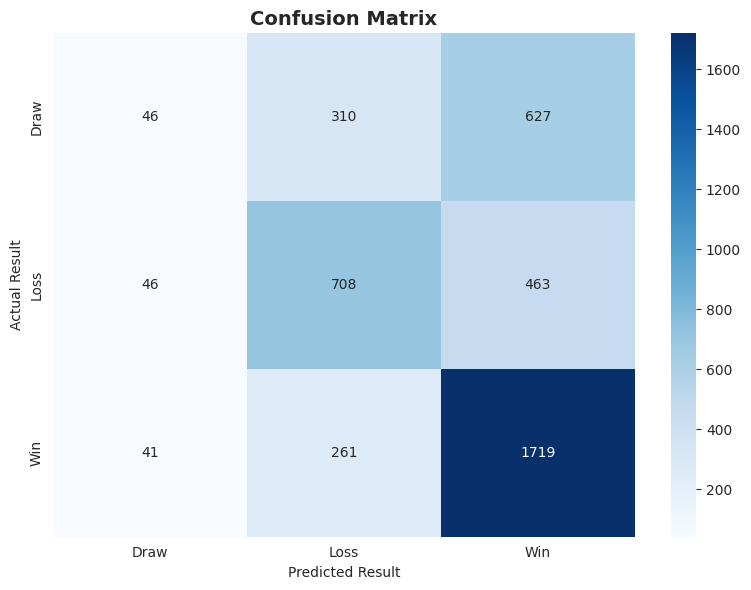


How to read the confusion matrix:
- Diagonal: Correct predictions
- Off-diagonal: Misclassifications


In [17]:
# Confusion Matrix - visualize prediction errors
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Result')
plt.xlabel('Predicted Result')
plt.tight_layout()
plt.show()

print("\nHow to read the confusion matrix:")
print("- Diagonal: Correct predictions")
print("- Off-diagonal: Misclassifications")

## Step 8: Feature Importance

Which features matter most for predictions?

Feature Importance:
              feature  importance
2       win_rate_diff    0.363295
1       away_win_rate    0.170873
0       home_win_rate    0.168433
6  away_total_matches    0.133472
5  home_total_matches    0.118655
3             is_home    0.026893
4        is_world_cup    0.018379


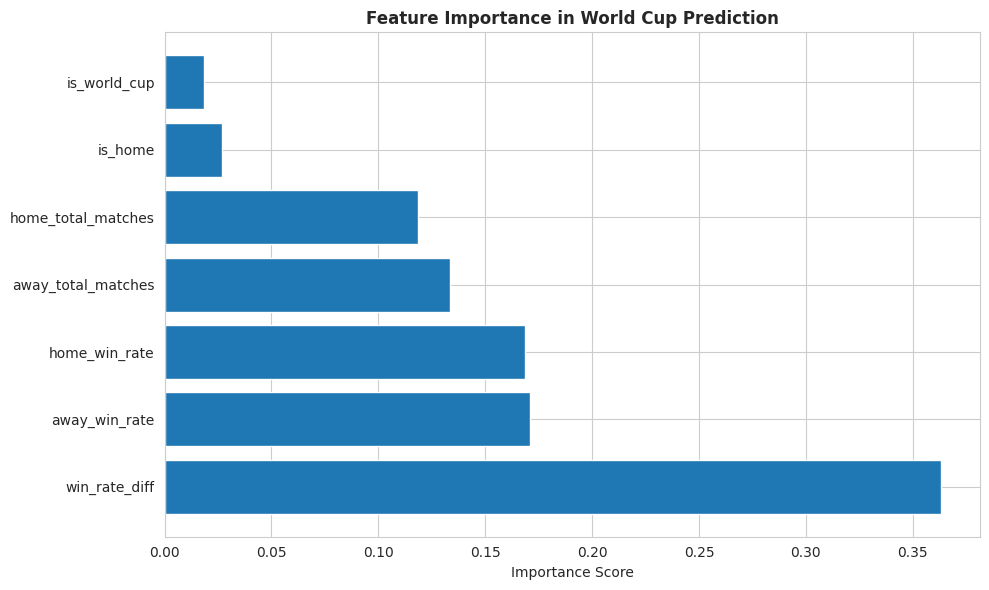

In [18]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance in World Cup Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Make Predictions for 2026 World Cup

Let's predict a hypothetical match:

In [19]:
def predict_match(home_team, away_team, is_neutral=False):
    """
    Predict outcome of a match between two teams
    """
    # Get team statistics
    home_stats = team_stats.get(home_team, {'win_rate': 0.5, 'total_matches': 0})
    away_stats = team_stats.get(away_team, {'win_rate': 0.5, 'total_matches': 0})
    
    # Create feature vector
    features = pd.DataFrame([{
        'home_win_rate': home_stats['win_rate'],
        'away_win_rate': away_stats['win_rate'],
        'win_rate_diff': home_stats['win_rate'] - away_stats['win_rate'],
        'is_home': 0 if is_neutral else 1,
        'is_world_cup': 1,
        'home_total_matches': home_stats['total_matches'],
        'away_total_matches': away_stats['total_matches']
    }])
    
    # Make prediction
    prediction = model.predict(features)[0]
    probabilities = model.predict_proba(features)[0]
    
    # Display results
    print(f"\n{'='*60}")
    print(f"Match Prediction: {home_team} vs {away_team}")
    print(f"{'='*60}")
    print(f"\nPredicted Outcome: {prediction}")
    print(f"\nProbabilities:")
    for outcome, prob in zip(model.classes_, probabilities):
        print(f"  {outcome}: {prob:.1%}")
    print(f"\nTeam Stats:")
    print(f"  {home_team} win rate: {home_stats['win_rate']:.1%}")
    print(f"  {away_team} win rate: {away_stats['win_rate']:.1%}")
    
    return prediction, probabilities

# Example predictions
predict_match('Brazil', 'Argentina', is_neutral=True)
predict_match('Germany', 'Spain', is_neutral=True)
predict_match('France', 'England', is_neutral=True)


Match Prediction: Brazil vs Argentina

Predicted Outcome: Win

Probabilities:
  Draw: 16.6%
  Loss: 36.3%
  Win: 47.1%

Team Stats:
  Brazil win rate: 65.1%
  Argentina win rate: 62.0%

Match Prediction: Germany vs Spain

Predicted Outcome: Loss

Probabilities:
  Draw: 23.5%
  Loss: 55.0%
  Win: 21.5%

Team Stats:
  Germany win rate: 60.1%
  Spain win rate: 70.1%

Match Prediction: France vs England

Predicted Outcome: Win

Probabilities:
  Draw: 17.4%
  Loss: 16.9%
  Win: 65.7%

Team Stats:
  France win rate: 60.0%
  England win rate: 62.1%


('Win', array([0.17374346, 0.16886105, 0.65739549]))

## Step 10: Model Limitations and Next Steps

### Current Limitations:
1. **Simple features**: Only uses win rates and match counts
2. **No recent form**: Doesn't consider last 5-10 games
3. **No player data**: Missing injuries, squad strength
4. **No tactical data**: Formation, playing style

### How to Improve:
1. **Add more features**:
   - FIFA rankings
   - Recent form (last N games)
   - Head-to-head record
   - Goals scored/conceded
   - Home continent advantage

2. **Try different models**:
   - Gradient Boosting (XGBoost, LightGBM)
   - Neural Networks
   - Ensemble methods

3. **Hyperparameter tuning**:
   - Use GridSearchCV or RandomizedSearchCV
   - Optimize n_estimators, max_depth, etc.

4. **Cross-validation**:
   - Use time-based splits
   - Validate on multiple folds

## Summary

### What We Did:
1. ✓ Loaded historical match data
2. ✓ Created features (team win rates, home advantage)
3. ✓ Trained a Random Forest classifier
4. ✓ Evaluated model performance
5. ✓ Made predictions for 2026 matches

### Key Takeaways:
- **Feature engineering is crucial**: Good features = better predictions
- **Model evaluation matters**: Accuracy isn't everything
- **Domain knowledge helps**: Understanding football improves feature selection
- **Iterate and improve**: Start simple, add complexity gradually

### Next Steps for You:
1. Experiment with different features
2. Try other ML algorithms
3. Add cross-validation
4. Build a simple web interface for predictions

**Remember**: ML is iterative. Keep experimenting! 🚀

In [20]:
# Save the model for future use
import joblib

joblib.dump(model, 'world_cup_model.pkl')
print("✓ Model saved as 'world_cup_model.pkl'")
print("\nYou can load it later with: model = joblib.load('world_cup_model.pkl')")

✓ Model saved as 'world_cup_model.pkl'

You can load it later with: model = joblib.load('world_cup_model.pkl')
